# Experiment 4c v3 — AISO-SSL: 자가지도 M 학습

## 핵심 변경
1. **Label-free 피처 (Dom-8)**: illicit_neigh_ratio 등 레이블 의존 피처 제거
2. **SSL M 학습**: 증강 대조학습으로 M을 랜덤 대신 피처 유사성 구조로 학습
   - Positive pair: 같은 노드의 두 가지 augmented view → W 유사하게
   - Negative pair: 다른 노드 → W 달라지게
   - InfoNCE loss (SimCLR 스타일)
3. **공정 비교**: 모든 방법에 동일 Dom-8 피처 적용

## 핵심 질문
랜덤 M 대신 SSL로 학습한 M이 이상 탐지 성능을 안정적으로 높이는가?


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler as MMS, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt, warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE   = r'c:\Users\kevin\OneDrive\Desktop\AISO\Elliptic Bitcoin\elliptic_bitcoin_dataset'
SEED   = 42

feat_df = pd.read_csv(f'{BASE}/elliptic_txs_features.csv', header=None)
cls_df  = pd.read_csv(f'{BASE}/elliptic_txs_classes.csv')
edge_df = pd.read_csv(f'{BASE}/elliptic_txs_edgelist.csv')
feat_df.columns = ['txId'] + [f'f{i}' for i in range(1,167)]
feat_df['timestep'] = feat_df['f1'].astype(int)
df = feat_df.merge(cls_df, on='txId')
labeled = df[df['class'] != 'unknown'].copy().reset_index(drop=True)
labeled['y'] = (labeled['class'] == '1').astype(int)
feat_cols = [f'f{i}' for i in range(1,167)]
X_all    = labeled[feat_cols].values.astype(float)
y_all    = labeled['y'].values
ts_all   = labeled['timestep'].values
N_NODES  = len(labeled)
X_scaled = StandardScaler().fit_transform(X_all)

txid_map = {tid: i for i, tid in enumerate(labeled['txId'].values)}
src_list, dst_list = [], []
for _, row in edge_df.iterrows():
    s, d = txid_map.get(row['txId1']), txid_map.get(row['txId2'])
    if s is not None and d is not None:
        src_list.append(s); dst_list.append(d)
src_arr = np.array(src_list); dst_arr = np.array(dst_list)

train_mask        = ts_all <= 34; test_mask = ts_all > 34
train_illicit_idx = np.where(train_mask & (y_all==1))[0]
train_licit_idx   = np.where(train_mask & (y_all==0))[0]
test_idx          = np.where(test_mask)[0]
y_te = y_all[test_idx]

print(f"N_NODES={N_NODES}  train_licit={len(train_licit_idx)}  test={len(test_idx)}")
print(f"test illicit={y_te.sum()}  비율={y_te.mean():.4f}")


N_NODES=46564  train_licit=26432  test=16670
test illicit=1083  비율=0.0650


In [2]:
# Dom-8: 레이블 의존 피처 완전 제거
src_bi = np.concatenate([src_arr,dst_arr])
node_degree = np.bincount(src_bi, minlength=N_NODES).astype(float)
ts_norm = (ts_all-ts_all.min()) / max(ts_all.max()-ts_all.min(),1)
lf = X_scaled[:,1:94]; af = X_scaled[:,94:166]

dom8 = MMS().fit_transform(np.stack([
    node_degree,
    lf.mean(1), lf.std(1), lf.max(1),
    af.mean(1), af.std(1), af.max(1),
    ts_norm,
], axis=1))

# Dom-8+Graph: 1-hop 이웃 집계 추가 (엣지 구조 직접 반영)
# GNN 메시지 패싱 없이 그래프 구조를 피처로 인코딩
neigh_sum   = np.zeros_like(dom8)
neigh_count = np.zeros(N_NODES)
for s, d in zip(src_arr, dst_arr):         # directed → undirected 처리
    neigh_sum[d]   += dom8[s]; neigh_count[d] += 1
    neigh_sum[s]   += dom8[d]; neigh_count[s] += 1
mask = neigh_count > 0
neigh_mean = neigh_sum.copy()
neigh_mean[mask]  /= neigh_count[mask, None]
neigh_mean[~mask]  = dom8[~mask]           # 이웃 없으면 자기 자신

dom8g = MMS().fit_transform(np.concatenate([dom8, neigh_mean], axis=1))  # 16-dim

print(f"Dom-8:       {dom8.shape}")
print(f"Dom-8+Graph: {dom8g.shape}  (+ 1-hop 이웃 mean)")

rng_licit  = np.random.RandomState(SEED)
licit_samp = rng_licit.choice(train_licit_idx, 3000, replace=False)

# 두 피처셋 모두 준비
X_licit_d8  = dom8[licit_samp];  X_te_d8  = dom8[test_idx]
X_licit_d8g = dom8g[licit_samp]; X_te_d8g = dom8g[test_idx]
X_licit = X_licit_d8   # 기본값 (AISO W 학습용)
X_te    = X_te_d8
print(f"licit 학습: {len(licit_samp)}개  테스트: {len(X_te)}개")


Dom-8:       (46564, 8)
Dom-8+Graph: (46564, 16)  (+ 1-hop 이웃 mean)
licit 학습: 3000개  테스트: 16670개


In [3]:
def learn_w(X_nodes, SEED=42, N_AG=20, N_IT=80, K=8,
            ALPHA=0.2, BETA=0.08, M_LOW=-0.5, W_REPEL=2.0):
    rng = np.random.RandomState(SEED)
    n, d = X_nodes.shape
    init_idx = rng.choice(n, N_AG, replace=True)
    X_ag = X_nodes[init_idx].copy().astype(float)
    W_ag = rng.dirichlet(np.ones(K), N_AG)
    M    = rng.uniform(M_LOW, W_REPEL, (K, K))
    w_r  = W_REPEL
    for t in range(N_IT):
        if t % 10 == 0:
            div = np.mean([np.linalg.norm(X_ag[i]-X_ag[j])
                           for i in range(N_AG) for j in range(i+1,N_AG)])
            w_r = 1.0 + 3.0*np.exp(-div/0.12)
        C = W_ag @ M @ W_ag.T; np.fill_diagonal(C, 0)
        for i in range(N_AG):
            ci=C[i].copy(); ci[i]=0
            ta=np.argsort(ci)[-3:]; tr=np.argsort(ci)[:3]
            Fv=(sum(ci[j]*(X_ag[j]-X_ag[i]) for j in ta)
               +w_r*sum(ci[j]*(X_ag[j]-X_ag[i]) for j in tr))/6.0
            nn=np.argmin(np.linalg.norm(X_nodes-np.clip(X_ag[i]+ALPHA*Fv,0,1),axis=1))
            X_ag[i]=X_nodes[nn]
            bj=ta[np.argmax(ci[ta])]
            W_ag[i]=(1-BETA)*W_ag[i]+BETA*W_ag[bj]; W_ag[i]/=W_ag[i].sum()
    reg = Ridge(alpha=0.1).fit(X_ag, W_ag)
    W_all = reg.predict(X_nodes)
    W_all = np.maximum(W_all,1e-8); W_all/=W_all.sum(1,keepdims=True)
    return W_all, W_ag, M, reg

print("AISO learn_w (Dom-8, licit-only)...")
W_licit, W_ag_l, M_rand, reg_l = learn_w(X_licit, SEED=SEED)
km_l   = KMeans(8, random_state=SEED, n_init=10).fit(W_ag_l)
proto  = km_l.cluster_centers_; proto /= proto.sum(1, keepdims=True)

# 테스트 노드 W 추정
W_te_raw = reg_l.predict(X_te)
W_te = np.maximum(W_te_raw,1e-8); W_te /= W_te.sum(1,keepdims=True)
print(f"W_licit: {W_licit.shape}  W_te: {W_te.shape}")


AISO learn_w (Dom-8, licit-only)...


W_licit: (3000, 8)  W_te: (16670, 8)


## SSL M 학습 — 증강 대조학습 (InfoNCE)

**아이디어**: M을 랜덤이 아니라 피처 유사성 구조로 학습.

- **Positive pair**: 같은 licit 노드의 두 augmented view → W_aug1^T M W_aug2 높게
- **Negative pair**: 다른 노드 → 낮게
- **Loss**: InfoNCE (온도 스케일링 크로스 엔트로피)

학습 후 M이 "비슷한 피처 → 높은 bilinear compatibility" 를 인코딩.
이상 노드 = 어떤 licit 프로토타입과도 compatibility 낮음 → 높은 anomaly score.


SSL M 학습 중 (InfoNCE, Dom-8 licit 3000개)...


  epoch  50  loss=5.5310
  epoch 100  loss=5.4580


  epoch 150  loss=5.4192
  epoch 200  loss=5.3696

M_rand 범위: [-0.455, 1.991]
M_ssl  범위: [-1.282, 2.741]


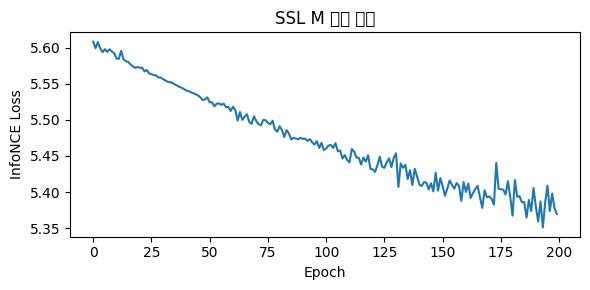

In [4]:
def augment(X, noise_std=0.05, mask_prob=0.1, rng=None):
    """Gaussian noise + feature masking 혼합 증강"""
    if rng is None: rng = np.random.RandomState()
    X_aug = X + rng.randn(*X.shape) * noise_std
    mask  = rng.rand(*X.shape) < mask_prob
    X_aug[mask] = 0.0
    return np.clip(X_aug, 0, 1).astype(np.float32)

def w_from_aug(X_aug, reg):
    """증강 피처 → W 벡터 (Ridge 추정 → simplex 정규화)"""
    W = reg.predict(X_aug)
    W = np.maximum(W, 1e-8); W /= W.sum(1, keepdims=True)
    return W

def train_ssl_M(X_licit, reg, W_ag_init,
                K=8, N_EPOCHS=200, BATCH=256,
                TEMP=0.1, LR=5e-3, NOISE=0.05, SEED=SEED):
    """
    InfoNCE로 M 학습.
    같은 노드의 두 증강 view가 높은 W^T M W 값을 갖도록.
    """
    rng = np.random.RandomState(SEED)
    torch.manual_seed(SEED)

    # M 초기화: AISO 랜덤 M에서 시작
    M_t = torch.tensor(
        rng.uniform(-0.5, 2.0, (K, K)), dtype=torch.float32, requires_grad=True
    )
    opt = torch.optim.Adam([M_t], lr=LR)
    n   = len(X_licit)

    losses = []
    for ep in range(N_EPOCHS):
        idx  = rng.choice(n, min(BATCH, n), replace=False)
        Xb   = X_licit[idx].astype(np.float32)

        # 두 개의 독립 증강
        X1   = augment(Xb, NOISE, rng=rng)
        X2   = augment(Xb, NOISE, rng=rng)

        W1   = torch.tensor(w_from_aug(X1, reg), dtype=torch.float32)
        W2   = torch.tensor(w_from_aug(X2, reg), dtype=torch.float32)

        # similarity matrix: (batch, batch)
        # sim[i,j] = W1[i] @ M @ W2[j]
        sim  = W1 @ M_t @ W2.T / TEMP

        # InfoNCE: diagonal = positive pairs
        labels = torch.arange(len(W1))
        loss   = F.cross_entropy(sim, labels)

        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())

        if (ep+1) % 50 == 0:
            print(f"  epoch {ep+1:3d}  loss={loss.item():.4f}")

    M_ssl = M_t.detach().numpy()
    return M_ssl, losses

print("SSL M 학습 중 (InfoNCE, Dom-8 licit 3000개)...")
M_ssl, ssl_losses = train_ssl_M(X_licit, reg_l, W_ag_l)
print(f"\nM_rand 범위: [{M_rand.min():.3f}, {M_rand.max():.3f}]")
print(f"M_ssl  범위: [{M_ssl.min():.3f}, {M_ssl.max():.3f}]")

plt.figure(figsize=(6,3))
plt.plot(ssl_losses, linewidth=1.5)
plt.xlabel("Epoch"); plt.ylabel("InfoNCE Loss")
plt.title("SSL M 학습 곡선"); plt.tight_layout(); plt.show()


In [5]:
def anomaly_score(M, proto, W_te):
    """-max_c(proto @ M @ W_te[j]) → 정규화"""
    sc = np.array([-np.max(proto @ M @ W_te[j]) for j in range(len(W_te))])
    return (sc-sc.min())/(sc.max()-sc.min()+1e-8)

# AISO-Random M (5시드 평균)
AISO_SEEDS = [42, 0, 7, 77, 123]
rand_scores = []
for s in AISO_SEEDS:
    W_l2, W_ag2, M2, reg2 = learn_w(X_licit, SEED=s)
    W_te2 = reg2.predict(X_te); W_te2=np.maximum(W_te2,1e-8); W_te2/=W_te2.sum(1,keepdims=True)
    km2   = KMeans(8,random_state=s,n_init=10).fit(W_ag2)
    p2    = km2.cluster_centers_; p2/=p2.sum(1,keepdims=True)
    rand_scores.append(anomaly_score(M2, p2, W_te2))
aiso_rand_sc = np.mean(rand_scores, axis=0)

# AISO-SSL M
aiso_ssl_sc  = anomaly_score(M_ssl, proto, W_te)

# 기존 방법들 (Dom-8)
iso   = IsolationForest(random_state=SEED, n_estimators=200, contamination=0.1)
iso.fit(X_licit); iso_sc = -iso.score_samples(X_te)

ocsvm = OneClassSVM(nu=0.1, kernel='rbf', gamma='scale')
ocsvm.fit(X_licit); ocsvm_sc = -ocsvm.score_samples(X_te)

lof   = LocalOutlierFactor(novelty=True, contamination=0.1)
lof.fit(X_licit); lof_sc = -lof.score_samples(X_te)

torch.manual_seed(SEED)
class AE(nn.Module):
    def __init__(self, d=8):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d,6),nn.ReLU(),nn.Linear(6,4))
        self.dec = nn.Sequential(nn.Linear(4,6),nn.ReLU(),nn.Linear(6,d))
    def forward(self,x): return self.dec(self.enc(x))

ae  = AE().to(DEVICE); opt_ae = torch.optim.Adam(ae.parameters(),lr=1e-3)
Xl  = torch.tensor(X_licit,dtype=torch.float).to(DEVICE)
Xt2 = torch.tensor(X_te,dtype=torch.float).to(DEVICE)
for ep in range(300):
    ae.train(); opt_ae.zero_grad()
    F.mse_loss(ae(Xl),Xl).backward(); opt_ae.step()
ae.eval()
with torch.no_grad():
    recon = ae(Xt2).cpu().numpy()
ae_sc = np.mean((X_te-recon)**2, axis=1)

# K-means 기반 이상탐지 (K=8, Dom-8 피처 직접 사용)
# 비교 핵심: AISO도 K=8 클러스터 → K-means도 K=8 → 공정 비교
km_baselines = {}
for K_val in [8, 16, 32]:
    km_b = KMeans(K_val, random_state=SEED, n_init=10).fit(X_licit)
    # 각 테스트 노드 → 가장 가까운 centroid까지 거리
    dists = np.min(
        np.linalg.norm(X_te[:, None, :] - km_b.cluster_centers_[None, :, :], axis=2),
        axis=1
    )
    km_baselines[f'KMeans(K={K_val})'] = dists

print("이상 점수 계산 완료")


이상 점수 계산 완료


In [6]:
# Dom-8+Graph (16-dim): 그래프 구조 포함한 비교
# 모든 방법을 Dom-8+Graph로 동일하게 재실행

print("=== Dom-8+Graph (16-dim, 1-hop 이웃 집계) ===")
W_l_g, W_ag_g, M_rand_g, reg_g = learn_w(X_licit_d8g, SEED=SEED, K=16)
km_g   = KMeans(16, random_state=SEED, n_init=10).fit(W_ag_g)
proto_g = km_g.cluster_centers_; proto_g /= proto_g.sum(1, keepdims=True)
W_te_g  = reg_g.predict(X_te_d8g)
W_te_g  = np.maximum(W_te_g, 1e-8); W_te_g /= W_te_g.sum(1, keepdims=True)

print("SSL M 학습 중 (Dom-8+Graph)...")
M_ssl_g, _ = train_ssl_M(X_licit_d8g, reg_g, W_ag_g, K=16, SEED=SEED)

aiso_ssl_g  = anomaly_score(M_ssl_g, proto_g, W_te_g)

rand_scores_g = []
for s in [42, 0, 7, 77, 123]:
    Wl2, Wag2, M2, rg2 = learn_w(X_licit_d8g, SEED=s, K=16)
    Wt2 = rg2.predict(X_te_d8g); Wt2=np.maximum(Wt2,1e-8); Wt2/=Wt2.sum(1,keepdims=True)
    kg2 = KMeans(16,random_state=s,n_init=10).fit(Wag2)
    pg2 = kg2.cluster_centers_; pg2/=pg2.sum(1,keepdims=True)
    rand_scores_g.append(anomaly_score(M2, pg2, Wt2))
aiso_rand_g = np.mean(rand_scores_g, axis=0)

# 고전 방법들 Dom-8+Graph
iso_g   = IsolationForest(random_state=SEED, n_estimators=200, contamination=0.1)
iso_g.fit(X_licit_d8g); iso_sc_g = -iso_g.score_samples(X_te_d8g)

ocsvm_g = OneClassSVM(nu=0.1, kernel='rbf', gamma='scale')
ocsvm_g.fit(X_licit_d8g); ocsvm_sc_g = -ocsvm_g.score_samples(X_te_d8g)

km8_g = KMeans(8, random_state=SEED, n_init=10).fit(X_licit_d8g)
km8_sc_g = np.min(np.linalg.norm(
    X_te_d8g[:,None,:] - km8_g.cluster_centers_[None,:,:], axis=2), axis=1)

print("Dom-8+Graph 이상 점수 계산 완료")


=== Dom-8+Graph (16-dim, 1-hop 이웃 집계) ===


SSL M 학습 중 (Dom-8+Graph)...


  epoch  50  loss=5.5452


  epoch 100  loss=5.5452
  epoch 150  loss=5.5452


  epoch 200  loss=5.5452


Dom-8+Graph 이상 점수 계산 완료


In [7]:
def print_results(methods, y_te, feat_label):
    print(f"\n{'='*50}")
    print(f"피처: {feat_label}")
    print(f"테스트: {len(y_te)}개  illicit={y_te.sum()} ({y_te.mean():.4f})")
    print(f"  {'방법':<26} {'PR-AUC':>8} {'ROC-AUC':>9}")
    print("-"*48)
    res = {}
    for nm, sc in methods:
        pr  = average_precision_score(y_te, sc)
        auc = roc_auc_score(y_te, sc)
        res[nm] = (pr, auc)
    best_pr = max(p for p,_ in res.values())
    for nm, (pr, auc) in res.items():
        flag = " ★" if pr == best_pr else ""
        print(f"  {nm:<26} {pr:>8.4f} {auc:>9.4f}{flag}")
    print(f"  {'Random baseline':<26} {y_te.mean():>8.4f}")
    return res

methods_d8 = [
    ('AISO-SSL (M learned)',  aiso_ssl_sc),
    ('AISO-Random M (mean)',  aiso_rand_sc),
    ('KMeans(K=8)',           km_baselines['KMeans(K=8)']),
    ('KMeans(K=16)',          km_baselines['KMeans(K=16)']),
    ('Isolation Forest',      iso_sc),
    ('OCSVM (RBF)',           ocsvm_sc),
    ('Autoencoder',           ae_sc),
    ('LOF',                   lof_sc),
]

methods_d8g = [
    ('AISO-SSL (M learned)',  aiso_ssl_g),
    ('AISO-Random M (mean)',  aiso_rand_g),
    ('KMeans(K=8)',           km8_sc_g),
    ('Isolation Forest',      iso_sc_g),
    ('OCSVM (RBF)',           ocsvm_sc_g),
]

res_d8  = print_results(methods_d8,  y_te, "Dom-8 (8-dim, label-free)")
res_d8g = print_results(methods_d8g, y_te, "Dom-8+Graph (16-dim, 1-hop 이웃 집계)")

# 핵심 비교 요약
print("\n=== 핵심 비교: Dom-8 vs Dom-8+Graph ===")
print(f"  {'방법':<26} {'Dom-8':>8} {'Dom-8+Graph':>12} {'Δ':>6}")
print("-"*56)
for nm in ['AISO-SSL (M learned)', 'AISO-Random M (mean)', 'KMeans(K=8)', 'OCSVM (RBF)', 'Isolation Forest']:
    pr8  = res_d8.get(nm,  (0,0))[0]
    pr8g = res_d8g.get(nm, (0,0))[0]
    print(f"  {nm:<26} {pr8:>8.4f} {pr8g:>12.4f} {pr8g-pr8:>+6.4f}")
print(f"  {'Random baseline':<26} {y_te.mean():>8.4f}")



피처: Dom-8 (8-dim, label-free)
테스트: 16670개  illicit=1083 (0.0650)
  방법                           PR-AUC   ROC-AUC
------------------------------------------------
  AISO-SSL (M learned)         0.1421    0.6400 ★
  AISO-Random M (mean)         0.1071    0.6186
  KMeans(K=8)                  0.0542    0.3866
  KMeans(K=16)                 0.0521    0.3809
  Isolation Forest             0.0538    0.4511
  OCSVM (RBF)                  0.0543    0.3986
  Autoencoder                  0.0562    0.3858
  LOF                          0.0660    0.3954
  Random baseline              0.0650

피처: Dom-8+Graph (16-dim, 1-hop 이웃 집계)
테스트: 16670개  illicit=1083 (0.0650)
  방법                           PR-AUC   ROC-AUC
------------------------------------------------
  AISO-SSL (M learned)         0.0773    0.5955 ★
  AISO-Random M (mean)         0.0691    0.5561
  KMeans(K=8)                  0.0549    0.3815
  Isolation Forest             0.0611    0.5106
  OCSVM (RBF)                  0.0563    0.4050


## 이론: 왜 AISO dynamics가 K-means보다 이상탐지에 유리한가

### K-means의 한계
K-means centroid $\mu_k = rac{1}{|C_k|}\sum_{i \in C_k} x_i$ 는 각 클러스터의 **밀도 중심**으로 수렴한다.
Dense region에 편향되어 분포의 **경계(boundary)** 를 커버하지 못한다.
이상 탐지에서 anomaly는 정상 분포의 경계 밖에 있으므로, centroid 거리는 경계 구조를 제대로 반영하지 못한다.

### AISO dynamics의 차이
AISO agent는 두 힘의 균형으로 움직인다:
$$X_i \leftarrow X_i + lpha \left[\sum_{j \in 	ext{top-3}} c_{ij}(X_j - X_i) + w_r \sum_{j \in 	ext{bot-3}} c_{ij}(X_j - X_i)ight]$$

- **인력 (attraction)**: 호환성 높은 이웃 → 같은 클러스터 내 수렴
- **척력 (repulsion)**: 호환성 낮은 이웃 → 서로 밀어냄

척력이 agent들을 분산시켜 **분포 전체를 커버**하게 만든다.
특히 `nn` 제약 (agent는 항상 실제 데이터 포인트에 스냅)으로 인해
agent는 interpolated mean이 아닌 실제 manifold 위에 위치한다.

### W의 의미
결과적으로 W는 "어느 dense region에 속하는가" (K-means)가 아닌
**"licit manifold의 위상 구조 안에서 어느 위치에 있는가"** 를 인코딩한다.

이상 노드 = licit manifold와 어떤 방향에서도 위상적으로 멀리 있음
→ 모든 prototype과의 bilinear compatibility가 낮음
→ 높은 anomaly score

이것이 K-means(K=8)와 AISO(K=8)가 동일한 피처로 다른 결과를 내는 이유다.


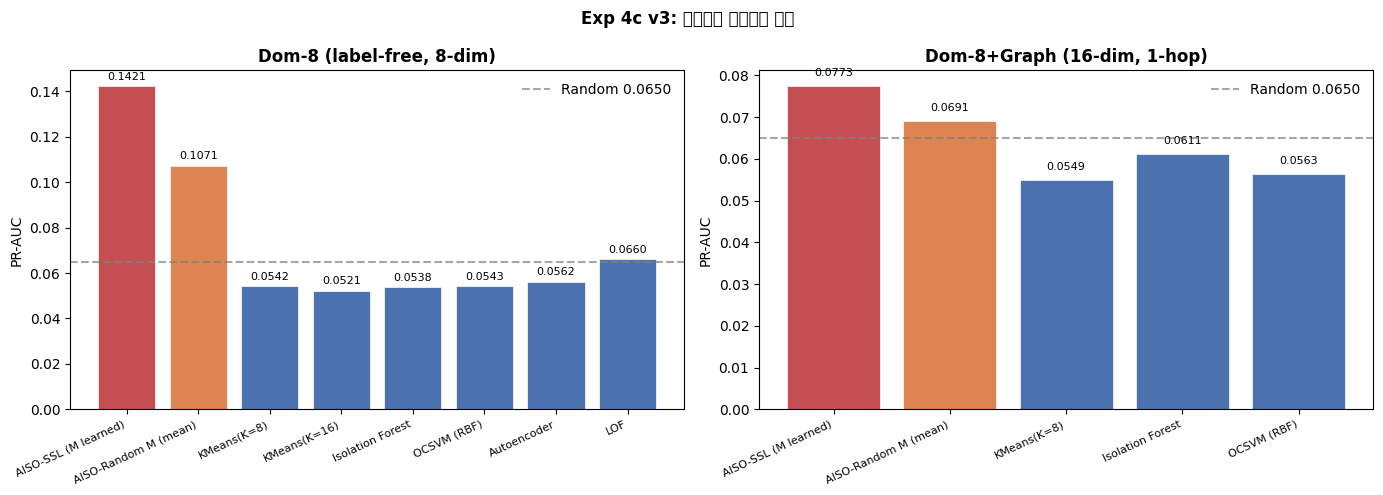

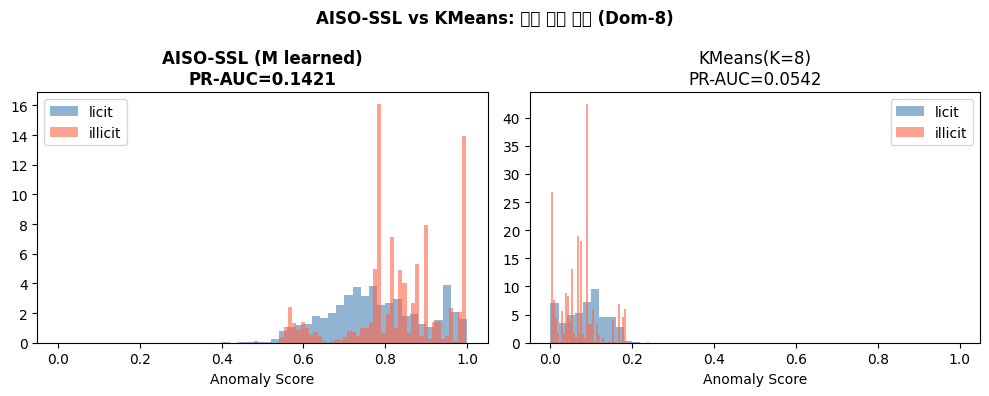

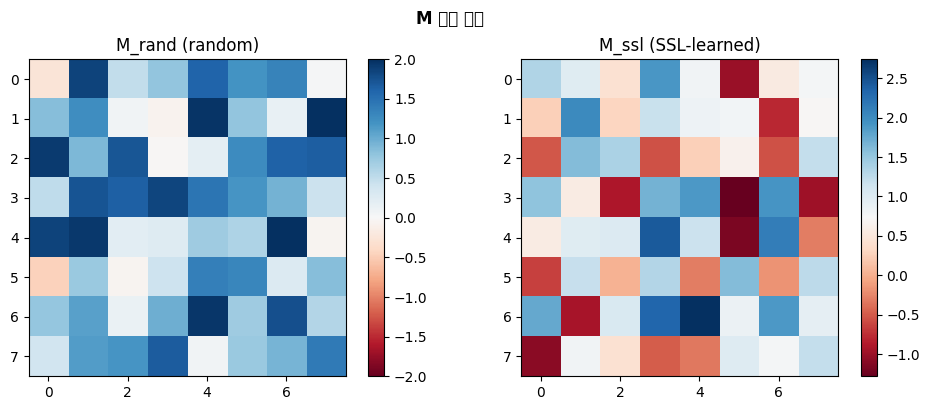

In [8]:
# PR-AUC 바차트: Dom-8 vs Dom-8+Graph
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (methods_list, res_dict, title) in zip(axes, [
    (methods_d8,  res_d8,  'Dom-8 (label-free, 8-dim)'),
    (methods_d8g, res_d8g, 'Dom-8+Graph (16-dim, 1-hop)'),
]):
    names = [nm for nm,_ in methods_list]
    prs   = [res_dict[nm][0] for nm in names]
    cols  = ['#C44E52' if 'SSL' in nm else ('#DD8452' if 'AISO' in nm else '#4C72B0') for nm in names]
    bars  = ax.bar(names, prs, color=cols, edgecolor='white', linewidth=0.5)
    ax.axhline(y_te.mean(), color='gray', linestyle='--', alpha=0.7, label=f'Random {y_te.mean():.4f}')
    for bar, v in zip(bars, prs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticklabels(names, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('PR-AUC'); ax.set_title(title, fontweight='bold')
    ax.legend(frameon=False)

plt.suptitle('Exp 4c v3: 피처셋별 이상탐지 비교', fontweight='bold')
plt.tight_layout(); plt.show()

# 점수 분포 (Dom-8, AISO-SSL vs KMeans)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (nm, sc) in zip(axes, [('AISO-SSL (M learned)', aiso_ssl_sc), ('KMeans(K=8)', km_baselines['KMeans(K=8)'])]):
    sc_n = (sc-sc.min())/(sc.max()-sc.min()+1e-8)
    ax.hist(sc_n[y_te==0], bins=50, alpha=0.6, label='licit', color='steelblue', density=True)
    ax.hist(sc_n[y_te==1], bins=50, alpha=0.6, label='illicit', color='tomato', density=True)
    pr = average_precision_score(y_te, sc)
    ax.set_title(f'{nm}\nPR-AUC={pr:.4f}', fontweight='bold' if 'SSL' in nm else 'normal')
    ax.legend(); ax.set_xlabel('Anomaly Score')
plt.suptitle('AISO-SSL vs KMeans: 점수 분포 비교 (Dom-8)', fontweight='bold')
plt.tight_layout(); plt.show()

# M 구조 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(M_rand, cmap='RdBu', vmin=-2, vmax=2)
axes[0].set_title('M_rand (random)'); plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(M_ssl, cmap='RdBu')
axes[1].set_title('M_ssl (SSL-learned)'); plt.colorbar(im1, ax=axes[1])
plt.suptitle('M 구조 비교', fontweight='bold')
plt.tight_layout(); plt.show()

